# AEA 논문 Replication Package 분석 (229004-V1)

**목적**: AEA 게재 논문의 replication package를 분석하여 아래 세 가지를 프로젝트에 반영한다.

1. `EU_sanctions_HS6.dta` → EU 제재 품목 HS6 리스트 추출 및 라벨링 기준 수립
2. 비정상 수출 산출 로직 파악 → semi-label 정의 근거
3. DiD 추정 구조 파악 → feature 설계 참고

**관련 이슈**: #6  
**패키지 경로**: `229004-V1/`

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# 한국어 폰트 설정
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PACKAGE_DIR = PROJECT_ROOT / "229004-V1"
RAW_DATA_DIR = PACKAGE_DIR / "Raw-data"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PACKAGE_DIR: {PACKAGE_DIR}")

PROJECT_ROOT: /Users/leejungyeon/Workspace/projects/무역통계경진대회/trade-circumvention-monitor
PACKAGE_DIR: /Users/leejungyeon/Workspace/projects/무역통계경진대회/trade-circumvention-monitor/229004-V1


---
## 1. EU 제재 품목 HS6 리스트 (`EU_sanctions_HS6.dta`)

EU Regulation 833/2014 기반의 HS6 단위 제재 품목 리스트다.  
각 HS6 코드별로 제재 카테고리(이중용도, 군사, 항공, 명품 등)가 플래그로 표시되어 있다.

In [9]:
sanctions_df = pd.read_stata(RAW_DATA_DIR / "EU_sanctions_HS6.dta")

print(f"shape: {sanctions_df.shape}")
print(f"\ndtypes:")
print(sanctions_df.dtypes)
print(f"\nnull 비율:")
print((sanctions_df.isnull().mean() * 100).round(1))

shape: (5369, 14)

dtypes:
Code                          str
Date                datetime64[s]
Winddowndate        datetime64[s]
partially_exempt          float32
Maxprice                  float64
aviation                  float32
dual_use                  float32
firearms                  float32
industrial_cap            float32
luxury                    float32
military_tech             float32
oil_exploration           float32
oil_refining              float32
EU_sanction               float32
dtype: object

null 비율:
Code                 0.0
Date                57.1
Winddowndate        57.1
partially_exempt    57.1
Maxprice            86.8
aviation            99.4
dual_use            83.9
firearms            99.6
industrial_cap      81.6
luxury              86.8
military_tech       90.5
oil_exploration     99.5
oil_refining        99.9
EU_sanction         57.1
dtype: float64


In [10]:
sanctions_df.head(10)

,Code,Date,Winddowndate,partially_exempt,Maxprice,aviation,dual_use,firearms,industrial_cap,luxury,military_tech,oil_exploration,oil_refining,EU_sanction
0,010121,2022-03-15,2022-03-15,0.0,300.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0
1,010129,2022-03-15,2022-03-15,1.0,300.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0
2,010130,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010190,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010221,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,010229,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,010231,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,010239,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,010290,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,010310,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1-1. 컬럼 설명

| 컬럼 | 의미 |
|------|------|
| `Code` | HS6 코드 (6자리) |
| `Date` | 제재 발효일 |
| `Winddowndate` | 유예 기간 종료일 (wind-down period) |
| `partially_exempt` | 일부 면제 여부 |
| `Maxprice` | 가격 상한선 (해당 시) |
| `aviation` | 항공 관련 품목 |
| `dual_use` | 이중용도 품목 (민간+군사 겸용) |
| `firearms` | 화기류 |
| `industrial_cap` | 산업 설비 |
| `luxury` | 명품·사치품 |
| `military_tech` | 군사 기술 |
| `oil_exploration` | 석유 탐사 관련 |
| `oil_refining` | 석유 정제 관련 |
| `EU_sanction` | EU 제재 여부 (1=제재, NaN=비제재) |

In [11]:
sanctioned_df = sanctions_df[sanctions_df["EU_sanction"] == 1].copy()

print(f"전체 HS6 코드 수: {len(sanctions_df):,}")
print(f"EU 제재 품목 수: {len(sanctioned_df):,}")
print(f"비제재 품목 수: {len(sanctions_df) - len(sanctioned_df):,}")

전체 HS6 코드 수: 5,369
EU 제재 품목 수: 2,304
비제재 품목 수: 3,065


카테고리별 제재 품목 수
industrial_cap     988
dual_use           865
luxury             707
military_tech      510
aviation            33
oil_exploration     26
firearms            24
oil_refining         8


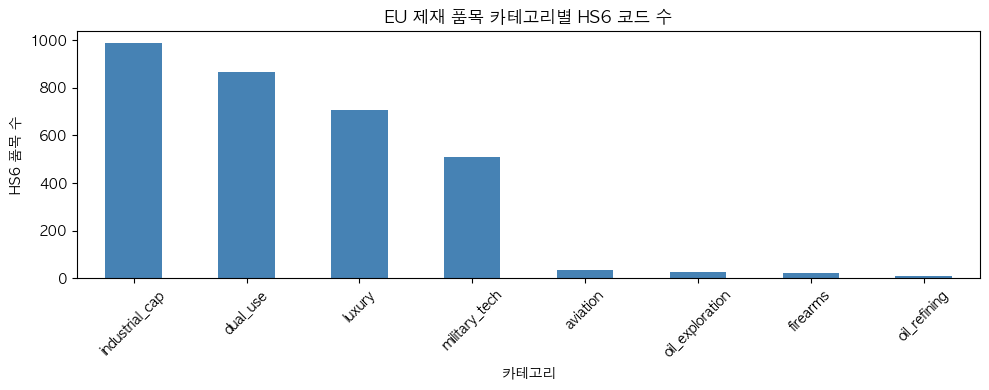

In [12]:
category_cols = ["aviation", "dual_use", "firearms", "industrial_cap",
                 "luxury", "military_tech", "oil_exploration", "oil_refining"]

category_counts = (
    sanctioned_df[category_cols]
    .sum()
    .sort_values(ascending=False)
    .rename("품목 수")
    .astype(int)
)

print("카테고리별 제재 품목 수")
print(category_counts.to_string())

plt.figure(figsize=(10, 4))
category_counts.plot(kind="bar", color="steelblue")
plt.title("EU 제재 품목 카테고리별 HS6 코드 수")
plt.xlabel("카테고리")
plt.ylabel("HS6 품목 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Figure 2.do 방식: 카테고리를 4개 그룹으로 분류
# 우선순위: dual-use > industrial > luxury > 기타
sanctioned_df = sanctioned_df.copy()
sanctioned_df["sanction_type"] = 0
sanctioned_df.loc[sanctioned_df["luxury"] == 1, "sanction_type"] = 1
sanctioned_df.loc[
    (sanctioned_df["aviation"] == 1) |
    (sanctioned_df["industrial_cap"] == 1) |
    (sanctioned_df["oil_exploration"] == 1) |
    (sanctioned_df["oil_refining"] == 1),
    "sanction_type"
] = 2
sanctioned_df.loc[
    (sanctioned_df["dual_use"] == 1) |
    (sanctioned_df["firearms"] == 1) |
    (sanctioned_df["military_tech"] == 1),
    "sanction_type"
] = 3

type_label = {0: "기타 제재", 1: "명품(Luxury)", 2: "산업(Industrial)", 3: "이중용도(Dual-use)"}
print("제재 유형별 품목 수")
print(
    sanctioned_df["sanction_type"]
    .value_counts()
    .rename(index=type_label)
    .sort_index()
    .to_string()
)

제재 유형별 품목 수
sanction_type
명품(Luxury)         570
산업(Industrial)     667
이중용도(Dual-use)    1067


In [14]:
print("제재 발효일 분포")
print(sanctioned_df["Date"].value_counts().sort_index())

제재 발효일 분포
Date
2016-12-22     17
2022-02-25    894
2022-03-15    583
2022-04-08    583
2022-06-04     30
2022-07-21     31
2022-10-06     30
2022-10-07      8
2022-12-16      2
2022-12-17      4
2023-02-25    122
Name: count, dtype: int64


---
## 2. 우리 프로젝트 HS 코드와 매핑

현재 프로젝트에서 수집한 품목(HS 7210, HS 8542)이 이 제재 리스트에 포함되어 있는지 확인한다.

In [15]:
our_hs_prefixes = ["7210", "8542"]

for prefix in our_hs_prefixes:
    matched = sanctioned_df[sanctioned_df["Code"].str.startswith(prefix)]
    print(f"\nHS {prefix} 계열 제재 품목: {len(matched)}개")
    if len(matched) > 0:
        print(matched[["Code", "Date", "sanction_type"] + category_cols].to_string())


HS 7210 계열 제재 품목: 11개
        Code       Date  sanction_type  aviation  dual_use  firearms  industrial_cap  luxury  military_tech  oil_exploration  oil_refining
3590  721011 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3591  721012 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3592  721020 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3593  721030 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3594  721041 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3595  721049 2023-02-25              2       NaN       NaN       NaN             1.0     NaN            NaN              NaN           NaN
3596

---
## 3. 제재 품목 리스트 저장

In [16]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "interim" / "eu_sanctions_hs6.csv"

export_df = sanctioned_df[["Code", "Date", "Winddowndate", "partially_exempt",
                            "sanction_type"] + category_cols].copy()

export_df.to_csv(OUTPUT_PATH, index=False)
print(f"저장 완료: {OUTPUT_PATH}")
print(f"저장 행 수: {len(export_df):,}")

저장 완료: /Users/leejungyeon/Workspace/projects/무역통계경진대회/trade-circumvention-monitor/data/interim/eu_sanctions_hs6.csv
저장 행 수: 2,304


---
## 4. 비정상 수출 산출 로직 분석 (`Clean monthly data.do` 참조)

### 논문의 데이터 전처리 흐름

1. UN Comtrade에서 EU/UK → CCA3(아르메니아·카자흐스탄·키르기스스탄) 월별 수출 데이터 수집
2. `partner2code == 0` 필터 → 직접 양자 무역만 (3국 경유 제외)
3. HS6 코드 앞자리 0 처리 (5자리 코드에 0 추가)
4. `EU_sanctions_HS6.dta`와 merge → 각 품목의 제재 카테고리 부여
5. 제재 유형별(luxury / industrial / dual-use) 월별 수출 합계 집계

### 우리 프로젝트에 적용할 semi-label 정의 방향

| 조건 | 라벨 |
|------|------|
| 제재 품목(`EU_sanction=1`) + 제재 이후 수출 급증 | `circumvention_candidate=1` |
| 비제재 품목 또는 제재 이전 증가 | `circumvention_candidate=0` |
| 제재 품목이나 데이터 결측 과다 | `uncertain` |

---
## 5. DiD 추정 구조 분석 (`Figure 2.do`, `Figure 3.do` 참조)

### 논문의 DiD 설계

- **Treatment**: EU 제재 품목 여부 (`EU_sanction=1`)
- **Control**: 비제재 품목 (`EU_sanction=0` or `NaN`)
- **기준 시점**: 2022년 2월 (러시아 제재 발효)
- **대상국**: CCA3 → 러시아 수출
- **제외국**: 조지아 (결측 과다)
- **집계 단위**: HS6 × 월

### 제재 유형 그룹화 (Figure 2.do)

```
sanction_type = 0: 비제재
sanction_type = 1: luxury (명품·사치품)
sanction_type = 2: industrial (aviation + industrial_cap + oil_exploration + oil_refining)
sanction_type = 3: dual-use (dual_use + firearms + military_tech)  ← 우회 탐지 핵심
```

### 우리 프로젝트 feature 설계 변수 후보

| 변수 | 설명 | 출처 |
|------|------|------|
| `is_sanctioned` | EU 제재 품목 여부 | `EU_sanctions_HS6.dta` |
| `sanction_type` | 제재 카테고리 (0~3) | 동 파일 |
| `sanction_date` | 제재 발효일 | 동 파일 |
| `months_since_sanction` | 제재 발효 후 경과 월 수 | 파생 변수 |
| `is_dual_use` | 이중용도 여부 | 우회 탐지 핵심 플래그 |
| `export_growth_post` | 제재 후 수출 증가율 | UN Comtrade 파생 |
| `post_pre_ratio` | 제재 전후 월평균 수출 배율 | 노트북 03 방식 재사용 |

---
## 6. 다음 단계

- [ ] `eu_sanctions_hs6.csv` 기준으로 수집 대상 HS6 코드 확정
- [ ] dual-use(`sanction_type=3`) 품목 우선 수집 (우회 탐지 핵심)
- [ ] UN Comtrade에서 CCA3 → 러시아 수출 데이터 HS6 단위로 재수집
- [ ] 제재 전후 비교 + 제재 품목 여부 결합 → semi-label 생성
- [ ] DiD feature(`months_since_sanction`, `is_sanctioned` 등) 피처 엔지니어링